# Human Activity Recognition using Hidden Markov Models

This notebook implements a data pipeline for collecting, preprocessing, and extracting features from smartphone sensor data (accelerometer and gyroscope) to classify four human activities: standing, walking, jumping, and still.

In [1]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.fft import fft, fftfreq
from sklearn.preprocessing import StandardScaler
import json
import logging

os.makedirs('logs', exist_ok=True)
logging.basicConfig(filename='logs/pipeline.log', level=logging.INFO,
                    format='%(asctime)s - %(message)s')
logger = logging.getLogger(__name__)

## 1. Data Loading

Load all sensor recordings from both team members. Each zip contains Accelerometer.csv, Gyroscope.csv, Metadata.csv, and Tags.csv.

- David: iPhone 14, 100Hz sampling rate (10ms interval)
- Queen: iPhone SE (2nd gen), 100Hz sampling rate (10ms interval)

Both phones were set to the same 100Hz sampling rate in Sensor Logger, so no resampling or interpolation was needed to harmonize the data. The timestamps and sample counts are directly comparable across both devices.

In [2]:
def get_activity_label(zip_path, default_label=None):
    with zipfile.ZipFile(zip_path) as z:
        if 'Tags.csv' in z.namelist():
            tags = z.read('Tags.csv').decode().strip().split('\n')
            if len(tags) > 1:
                tag = tags[1].strip().lower()
                if 'standing' in tag:
                    return 'standing'
                elif 'walking' in tag:
                    return 'walking'
                elif 'jumping' in tag:
                    return 'jumping'
                elif 'still' in tag or 'rest' in tag:
                    return 'still'
        
        name = os.path.basename(zip_path).lower()
        if 'standing' in name:
            return 'standing'
        elif 'walking' in name:
            return 'walking'
        elif 'jumping' in name:
            return 'jumping'
        elif 'still' in name or 'rest' in name or 'phone_at_rest' in name:
            return 'still'
    
    return default_label


def load_sensor_data(zip_path):
    with zipfile.ZipFile(zip_path) as z:
        accel = pd.read_csv(z.open('Accelerometer.csv'))
        gyro = pd.read_csv(z.open('Gyroscope.csv'))
    return accel, gyro


def load_all_data(data_dirs, default_labels=None):
    records = []
    for dir_path, default_label in zip(data_dirs, default_labels or [None]*len(data_dirs)):
        member = os.path.basename(dir_path)
        for fname in sorted(os.listdir(dir_path)):
            if not fname.endswith('.zip'):
                continue
            zip_path = os.path.join(dir_path, fname)
            label = get_activity_label(zip_path, default_label)
            if label is None:
                logger.warning(f'skipping {fname}, no label found')
                continue
            accel, gyro = load_sensor_data(zip_path)
            records.append({
                'file': fname,
                'member': member,
                'activity': label,
                'accel': accel,
                'gyro': gyro,
                'n_samples_accel': len(accel),
                'n_samples_gyro': len(gyro),
                'duration_s': accel['seconds_elapsed'].iloc[-1] - accel['seconds_elapsed'].iloc[0]
            })
            logger.info(f'loaded {fname} | {member} | {label} | {len(accel)} accel samples')
    return records

In [ ]:
david_tagged = 'data/david'
queen_dir = 'data/queen'

records = load_all_data(
    [david_tagged, queen_dir],
    default_labels=['still', None]
)

unseen_records = []
for member, activity in [('david', 'walking'), ('queen', 'jumping')]:
    candidates = [r for r in records if r['member'] == member and r['activity'] == activity]
    held_out = candidates[-1]
    unseen_records.append(held_out)
    records.remove(held_out)

print(f"held out for unseen testing:")
for r in unseen_records:
    print(f"  {r['file']} ({r['activity']}, {r['member']})")

summary = pd.DataFrame([{
    'file': r['file'], 'member': r['member'], 'activity': r['activity'],
    'accel_samples': r['n_samples_accel'], 'duration_s': round(r['duration_s'], 2)
} for r in records])

print(f"\ntraining recordings: {len(records)}")
print(summary.groupby(['member', 'activity']).size().unstack(fill_value=0))
print(f"\ntotal duration per activity:")
print(summary.groupby('activity')['duration_s'].sum())

## 2. Data Visualization

Plot sample accelerometer and gyroscope signals for each activity to understand the data patterns.

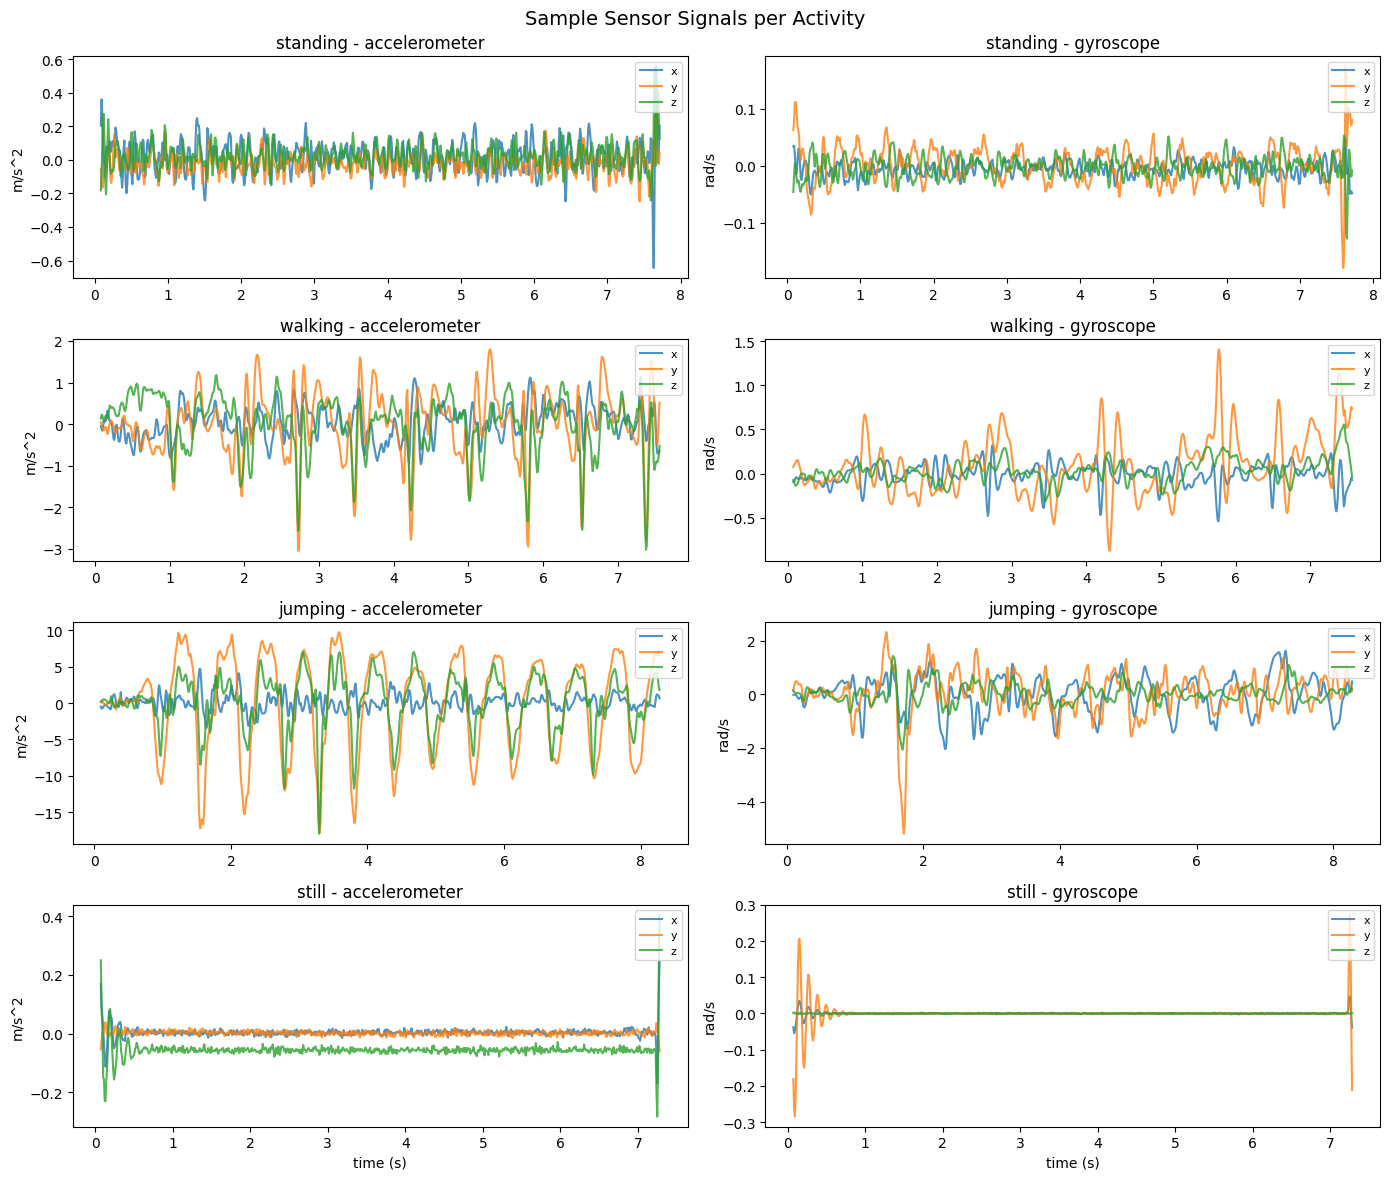

In [4]:
activities = ['standing', 'walking', 'jumping', 'still']

fig, axes = plt.subplots(4, 2, figsize=(14, 12))
fig.suptitle('Sample Sensor Signals per Activity', fontsize=14)

for i, activity in enumerate(activities):
    sample = [r for r in records if r['activity'] == activity][0]
    accel = sample['accel']
    gyro = sample['gyro']
    t = accel['seconds_elapsed']
    
    axes[i, 0].plot(t, accel['x'], label='x', alpha=0.8)
    axes[i, 0].plot(t, accel['y'], label='y', alpha=0.8)
    axes[i, 0].plot(t, accel['z'], label='z', alpha=0.8)
    axes[i, 0].set_title(f'{activity} - accelerometer')
    axes[i, 0].set_ylabel('m/s^2')
    axes[i, 0].legend(loc='upper right', fontsize=8)
    
    t_g = gyro['seconds_elapsed']
    axes[i, 1].plot(t_g, gyro['x'], label='x', alpha=0.8)
    axes[i, 1].plot(t_g, gyro['y'], label='y', alpha=0.8)
    axes[i, 1].plot(t_g, gyro['z'], label='z', alpha=0.8)
    axes[i, 1].set_title(f'{activity} - gyroscope')
    axes[i, 1].set_ylabel('rad/s')
    axes[i, 1].legend(loc='upper right', fontsize=8)

axes[-1, 0].set_xlabel('time (s)')
axes[-1, 1].set_xlabel('time (s)')
plt.tight_layout()
plt.savefig('logs/raw_signals.png', dpi=150)
plt.show()

## 3. Windowing and Feature Extraction

At 100Hz, we use a 1-second window (100 samples) with 50% overlap. This gives us enough data per window to capture one full gait cycle for walking (~1s) and multiple jump cycles, while keeping the window short enough to represent a single activity.

Features extracted per window:

**Time-domain:**
- Mean (per axis) — captures the average orientation/movement
- Variance (per axis) — captures intensity of movement
- RMS (root mean square of magnitude) — overall signal energy
- SMA (signal magnitude area) — total acceleration across all axes
- Correlation between axes — captures directional relationships

**Frequency-domain:**
- Dominant frequency from FFT — captures repetitive motion patterns
- Spectral energy — total power in the frequency spectrum

In [5]:
SAMPLING_RATE = 100
WINDOW_SIZE = 100
OVERLAP = 50

def compute_features(accel_window, gyro_window, sampling_rate=SAMPLING_RATE):
    ax, ay, az = accel_window['x'].values, accel_window['y'].values, accel_window['z'].values
    gx, gy, gz = gyro_window['x'].values, gyro_window['y'].values, gyro_window['z'].values
    
    accel_mag = np.sqrt(ax**2 + ay**2 + az**2)
    gyro_mag = np.sqrt(gx**2 + gy**2 + gz**2)
    
    features = {}
    
    features['accel_mean_x'] = np.mean(ax)
    features['accel_mean_y'] = np.mean(ay)
    features['accel_mean_z'] = np.mean(az)
    
    features['accel_var_x'] = np.var(ax)
    features['accel_var_y'] = np.var(ay)
    features['accel_var_z'] = np.var(az)
    
    features['accel_rms'] = np.sqrt(np.mean(accel_mag**2))
    
    features['accel_sma'] = np.sum(np.abs(ax) + np.abs(ay) + np.abs(az)) / len(ax)
    
    if np.std(ax) > 0 and np.std(ay) > 0:
        features['accel_corr_xy'] = np.corrcoef(ax, ay)[0, 1]
    else:
        features['accel_corr_xy'] = 0.0
    if np.std(ax) > 0 and np.std(az) > 0:
        features['accel_corr_xz'] = np.corrcoef(ax, az)[0, 1]
    else:
        features['accel_corr_xz'] = 0.0
    
    features['gyro_mean_x'] = np.mean(gx)
    features['gyro_mean_y'] = np.mean(gy)
    features['gyro_mean_z'] = np.mean(gz)
    
    features['gyro_var_x'] = np.var(gx)
    features['gyro_var_y'] = np.var(gy)
    features['gyro_var_z'] = np.var(gz)
    
    n = len(accel_mag)
    freqs = fftfreq(n, d=1.0/sampling_rate)[:n//2]
    
    accel_fft = np.abs(fft(accel_mag))[:n//2]
    features['accel_dominant_freq'] = freqs[np.argmax(accel_fft[1:]) + 1]
    features['accel_spectral_energy'] = np.sum(accel_fft**2) / n
    
    gyro_fft = np.abs(fft(gyro_mag))[:n//2]
    features['gyro_dominant_freq'] = freqs[np.argmax(gyro_fft[1:]) + 1]
    features['gyro_spectral_energy'] = np.sum(gyro_fft**2) / n
    
    return features


def extract_windows(accel, gyro, window_size=WINDOW_SIZE, overlap=OVERLAP):
    windows = []
    step = window_size - overlap
    min_len = min(len(accel), len(gyro))
    for start in range(0, min_len - window_size + 1, step):
        end = start + window_size
        windows.append((accel.iloc[start:end], gyro.iloc[start:end]))
    return windows


def extract_features(records):
    all_features = []
    all_labels = []
    all_meta = []
    
    for rec in records:
        windows = extract_windows(rec['accel'], rec['gyro'])
        for w_idx, (accel_w, gyro_w) in enumerate(windows):
            feats = compute_features(accel_w, gyro_w)
            all_features.append(feats)
            all_labels.append(rec['activity'])
            all_meta.append({'file': rec['file'], 'member': rec['member'], 'window': w_idx})
    
    feature_df = pd.DataFrame(all_features)
    labels = np.array(all_labels)
    
    logger.info(f'extracted {len(feature_df)} windows with {len(feature_df.columns)} features')
    return feature_df, labels, all_meta

In [6]:
feature_df, labels, meta = extract_features(records)

print(f"total windows: {len(feature_df)}")
print(f"features per window: {len(feature_df.columns)}")
print(f"\nwindows per activity:")
for act in activities:
    print(f"  {act}: {np.sum(labels == act)}")

feature_df.head()

total windows: 695
features per window: 20

windows per activity:
  standing: 186
  walking: 162
  jumping: 165
  still: 182


,accel_mean_x,accel_mean_y,accel_mean_z,accel_var_x,accel_var_y,accel_var_z,accel_rms,accel_sma,accel_corr_xy,accel_corr_xz,gyro_mean_x,gyro_mean_y,gyro_mean_z,gyro_var_x,gyro_var_y,gyro_var_z,accel_dominant_freq,accel_spectral_energy,gyro_dominant_freq,gyro_spectral_energy
0,0.029742,-0.020677,0.023360,0.009537,0.004390,0.008073,0.154462,0.211023,-0.056426,-0.018650,-0.009946,0.007362,-0.005532,0.000286,0.001617,0.000410,6.0,2.168152,5.0,0.225767
1,0.017814,-0.023371,0.019975,0.010585,0.004100,0.004218,0.142004,0.191393,0.115648,0.252339,-0.007607,0.009754,-0.002867,0.000176,0.000699,0.000395,13.0,1.864576,3.0,0.132660
2,0.016079,-0.024928,0.013564,0.011249,0.002928,0.003340,0.136312,0.182868,0.020827,0.192902,-0.005691,0.007131,-0.005079,0.000097,0.000677,0.000429,2.0,1.729214,2.0,0.119625
3,0.022853,-0.024340,0.015078,0.007155,0.003326,0.004621,0.128237,0.179854,-0.021899,0.253058,-0.006035,0.004447,-0.004729,0.000132,0.000459,0.000298,15.0,1.529689,1.0,0.089664
4,0.023249,-0.022991,0.020832,0.006427,0.003881,0.003612,0.124194,0.170006,-0.130554,0.249155,-0.003876,0.001435,-0.001449,0.000144,0.000411,0.000246,2.0,1.401233,4.0,0.076039


## 4. Normalization

Z-score normalization is applied to ensure all features are on the same scale. This is important because features like spectral energy can be orders of magnitude larger than correlation values, and the HMM emission probabilities would be dominated by high-magnitude features otherwise.

In [7]:
scaler = StandardScaler()
X = scaler.fit_transform(feature_df.values)
feature_names = feature_df.columns.tolist()

label_map = {act: i for i, act in enumerate(activities)}
y = np.array([label_map[l] for l in labels])

print(f"feature matrix shape: {X.shape}")
print(f"labels shape: {y.shape}")
print(f"label mapping: {label_map}")

feature matrix shape: (695, 20)
labels shape: (695,)
label mapping: {'standing': 0, 'walking': 1, 'jumping': 2, 'still': 3}


## 5. Feature Distribution Visualization

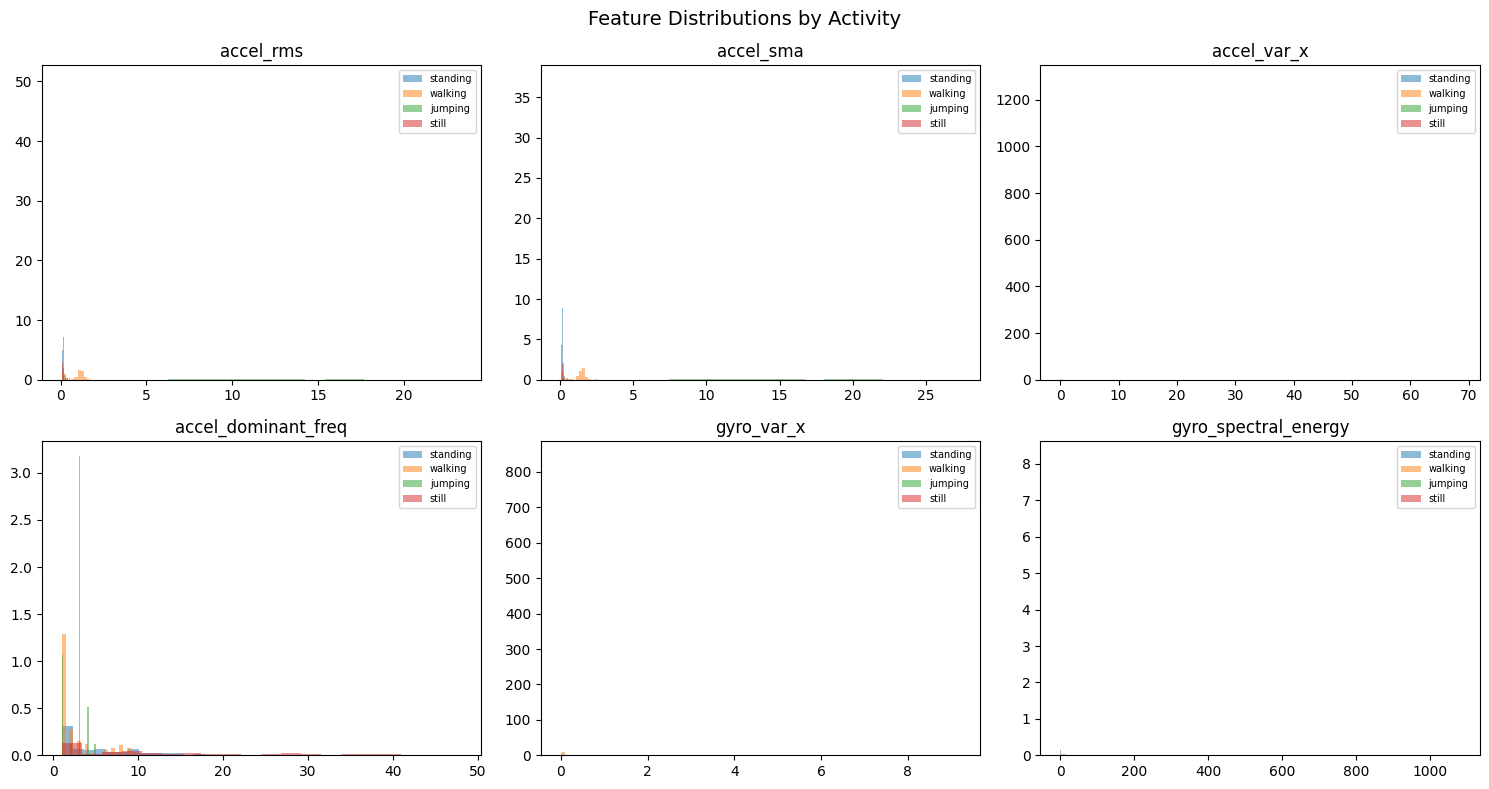

In [8]:
key_features = ['accel_rms', 'accel_sma', 'accel_var_x', 'accel_dominant_freq',
                 'gyro_var_x', 'gyro_spectral_energy']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Feature Distributions by Activity', fontsize=14)

for idx, feat in enumerate(key_features):
    ax = axes[idx // 3, idx % 3]
    for act in activities:
        mask = labels == act
        ax.hist(feature_df[feat][mask], bins=20, alpha=0.5, label=act, density=True)
    ax.set_title(feat)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('logs/feature_distributions.png', dpi=150)
plt.show()

## 6. Baum-Welch Training

Train the HMM using the Baum-Welch (EM) algorithm with a Gaussian emission model. The emission parameters (means and covariances) are initialized from the labeled training data so that each HMM state corresponds directly to an activity. Baum-Welch then optimizes the transition matrix and initial state probabilities, with convergence checked by monitoring the change in log-likelihood between iterations (stopping when the improvement drops below epsilon = 1e-4).

Each recording is treated as a separate observation sequence using the `lengths` parameter, which preserves the temporal structure within recordings and prevents artificial transitions between unrelated files.

In [ ]:
from hmmlearn.hmm import GaussianHMM

n_states = 4
n_features = X.shape[1]

init_means = np.zeros((n_states, n_features))
init_covars = np.zeros((n_states, n_features, n_features))
for s in range(n_states):
    mask = y == s
    init_means[s] = X[mask].mean(axis=0)
    init_covars[s] = np.cov(X[mask].T) + 1e-3 * np.eye(n_features)

init_startprob = np.ones(n_states) / n_states
init_transmat = 0.9 * np.eye(n_states) + 0.1 / (n_states - 1) * (1 - np.eye(n_states))

lengths = []
for rec in records:
    n_windows = (min(len(rec['accel']), len(rec['gyro'])) - WINDOW_SIZE) // (WINDOW_SIZE - OVERLAP) + 1
    if n_windows > 0:
        lengths.append(n_windows)

model = GaussianHMM(
    n_components=n_states,
    covariance_type='full',
    n_iter=200,
    tol=1e-4,
    random_state=42,
    verbose=True,
    init_params='',
    params='st'
)

model.means_ = init_means
model.covars_ = init_covars
model.startprob_ = init_startprob
model.transmat_ = init_transmat

model.fit(X, lengths=lengths)

training_history = {
    'converged': model.monitor_.converged,
    'n_iter': model.monitor_.iter,
    'log_likelihood': model.score(X)
}

print(f"converged: {training_history['converged']}")
print(f"iterations: {training_history['n_iter']}")
print(f"log-likelihood: {training_history['log_likelihood']:.2f}")

with open('logs/training_history.json', 'w') as f:
    json.dump(training_history, f, indent=2)

logger.info(f"training complete: {training_history}")

In [10]:
print("learned transition matrix:")
print(np.round(model.transmat_, 3))
print(f"\ninitial state probabilities: {np.round(model.startprob_, 3)}")

learned transition matrix:
[[0.921 0.079 0.    0.   ]
 [0.116 0.855 0.029 0.   ]
 [0.    0.038 0.929 0.032]
 [0.    0.    0.333 0.667]]

initial state probabilities: [1. 0. 0. 0.]


## 7. Save Outputs for Part 2 (Evaluation)

Save the trained model, feature matrix, labels, scaler, and metadata so Queen can load them directly for Viterbi decoding and evaluation.

In [11]:
import pickle

os.makedirs('outputs', exist_ok=True)

np.savez('outputs/features.npz', X=X, y=y, feature_names=feature_names)

with open('outputs/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('outputs/model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('outputs/label_map.json', 'w') as f:
    json.dump(label_map, f)

with open('outputs/meta.json', 'w') as f:
    json.dump(meta, f)

print("saved to outputs/:")
for fname in os.listdir('outputs'):
    fsize = os.path.getsize(f'outputs/{fname}')
    print(f"  {fname} ({fsize} bytes)")

saved to outputs/:
  features.npz (119188 bytes)
  label_map.json (55 bytes)
  meta.json (51829 bytes)
  model.pkl (14496 bytes)
  scaler.pkl (930 bytes)


## 8. HMM Structure: 4 Hidden States

We define and extract the learned parameters from the trained GaussianHMM model to define the HMM completely:
- **4 hidden states** — one per activity: `standing`, `walking`, `jumping`, `still`
- **Transition matrix A** — learned by Baum-Welch; each entry `A[i,j]` = P(next state = j | current state = i)
- **Emission probabilities B** — Gaussian means and covariances for each state
- **Initial Probabilities π** — Starting state distribution(learned from training data)

In [12]:
# ── Load saved artifacts ──────────────────────────────────────────────────────
with open('outputs/model.pkl', 'rb') as f:
    model = pickle.load(f)

data = np.load('outputs/features.npz', allow_pickle=True)
X      = data['X']
y      = data['y']
feature_names = data['feature_names'].tolist()

with open('outputs/label_map.json') as f:
    label_map = json.load(f)

activities   = ['standing', 'walking', 'jumping', 'still']
idx_to_act   = {v: k for k, v in label_map.items()}
n_states     = model.n_components

# ── Extract HMM parameters ───────────────────────────────────────────────────
A       = model.transmat_          # (4, 4)  transition matrix
pi      = model.startprob_         # (4,)    initial distribution
means   = model.means_             # (4, n_features)  emission means
covars  = model.covars_            # (4, n_features, n_features)  full covariances

print("-" * 60)
print(f"Number of hidden states  : {n_states}")
print(f"State → Activity mapping : {label_map}")
print()
print("Initial state probabilities π:")
for i, p in enumerate(pi):
    print(f"  State {i} ({activities[i]:10s}): {p:.4f}")
print()
print("Transition matrix A (rows = from, cols = to):")
df_A = pd.DataFrame(np.round(A, 4),
                    index=[f'from {a}' for a in activities],
                    columns=[f'to {a}' for a in activities])
print(df_A.to_string())
print()
print("Emission means (first 5 features per state):")
df_means = pd.DataFrame(means[:, :5],
                        index=activities,
                        columns=feature_names[:5])
print(df_means.round(3).to_string())

------------------------------------------------------------
Number of hidden states  : 4
State → Activity mapping : {'standing': 0, 'walking': 1, 'jumping': 2, 'still': 3}

Initial state probabilities π:
  State 0 (standing  ): 1.0000
  State 1 (walking   ): 0.0000
  State 2 (jumping   ): 0.0000
  State 3 (still     ): 0.0000

Transition matrix A (rows = from, cols = to):
               to standing  to walking  to jumping  to still
from standing       0.9209      0.0791      0.0000    0.0000
from walking        0.1159      0.8551      0.0290    0.0000
from jumping        0.0000      0.0385      0.9295    0.0321
from still          0.0000      0.0000      0.3333    0.6667

Emission means (first 5 features per state):
          accel_mean_x  accel_mean_y  accel_mean_z  accel_var_x  accel_var_y
standing        -0.035        -0.097         0.128       -0.265       -0.361
walking         -0.165        -0.026         0.113       -0.247       -0.355
jumping          0.490         0.058      

## 9. Viterbi Algorithm

The Viterbi algorithm finds the single most-probable hidden state sequence given an observation sequence and the HMM parameters.

**Algorithm (log-domain for numerical stability):**
1. **Initialization** — `δ[0, i] = log π[i] + log B(o₀ | i)`
2. **Recursion** — `δ[t, j] = max_i [ δ[t-1, i] + log A[i,j] ] + log B(oₜ | j)`
3. **Backtrack** — trace the argmax pointers to recover the optimal path

Gaussian log-likelihood: `log B(o | i) = -0.5 * [ (o - μᵢ)ᵀ Σᵢ⁻¹ (o - μᵢ) + log|2π Σᵢ| ]`

In [13]:
from scipy.stats import multivariate_normal

def gaussian_log_likelihood(obs_seq, means, covars):
    """
    Compute log emission probabilities for every (timestep, state) pair.
    obs_seq : (T, n_features)
    means   : (n_states, n_features)
    covars  : (n_states, n_features, n_features)  [full covariance]
    Returns : (T, n_states)
    """
    T        = obs_seq.shape[0]
    n_states = means.shape[0]
    log_B    = np.zeros((T, n_states))
    for s in range(n_states):
        try:
            rv          = multivariate_normal(mean=means[s], cov=covars[s], allow_singular=True)
            log_B[:, s] = rv.logpdf(obs_seq)
        except Exception:
            log_B[:, s] = -1e18   # degenerate state — assign near-zero probability
    return log_B


def viterbi(obs_seq, pi, A, means, covars):
    """
    Viterbi decoding in log-domain.

    Parameters
    ----------
    obs_seq : (T, n_features)  observation sequence
    pi      : (n_states,)      initial state distribution
    A       : (n_states, n_states)  row-stochastic transition matrix
    means   : (n_states, n_features)
    covars  : (n_states, n_features, n_features)

    Returns
    -------
    best_path  : list[int]  length T, most-likely state sequence
    best_score : float      log-probability of that path
    delta      : (T, n_states)  Viterbi lattice (for inspection)
    """
    T        = obs_seq.shape[0]
    n_states = pi.shape[0]

    log_pi   = np.log(pi   + 1e-300)
    log_A    = np.log(A    + 1e-300)
    log_B    = gaussian_log_likelihood(obs_seq, means, covars)

    # ── Forward pass ──────────────────────────────────────────────────────────
    delta   = np.full((T, n_states), -np.inf)
    psi     = np.zeros((T, n_states), dtype=int)

    delta[0] = log_pi + log_B[0]   # initialisation

    for t in range(1, T):
        for j in range(n_states):
            scores      = delta[t-1] + log_A[:, j]
            psi[t, j]   = np.argmax(scores)
            delta[t, j] = scores[psi[t, j]] + log_B[t, j]

    # ── Backtrack ─────────────────────────────────────────────────────────────
    best_path        = np.zeros(T, dtype=int)
    best_path[-1]    = np.argmax(delta[-1])
    best_score       = delta[-1, best_path[-1]]

    for t in range(T - 2, -1, -1):
        best_path[t] = psi[t + 1, best_path[t + 1]]

    return best_path.tolist(), best_score, delta


print("Viterbi function defined.")
print("Quick smoke-test on 10 windows from training data...")
test_obs  = X[:10]
path, score, _ = viterbi(test_obs, pi, A, means, covars)
print("  decoded states :", path)
print("  log-prob       :", round(score, 2))
print("  (hmmlearn)     :", model.decode(test_obs, algorithm='viterbi')[1][:10])

Viterbi function defined.
Quick smoke-test on 10 windows from training data...
  decoded states : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  log-prob       : -59.61
  (hmmlearn)     : [0 0 0 0 0 0 0 0 0 0]


## 10. Visualizations: Transition Matrix, Emission Probabilities, Decoded Sequences

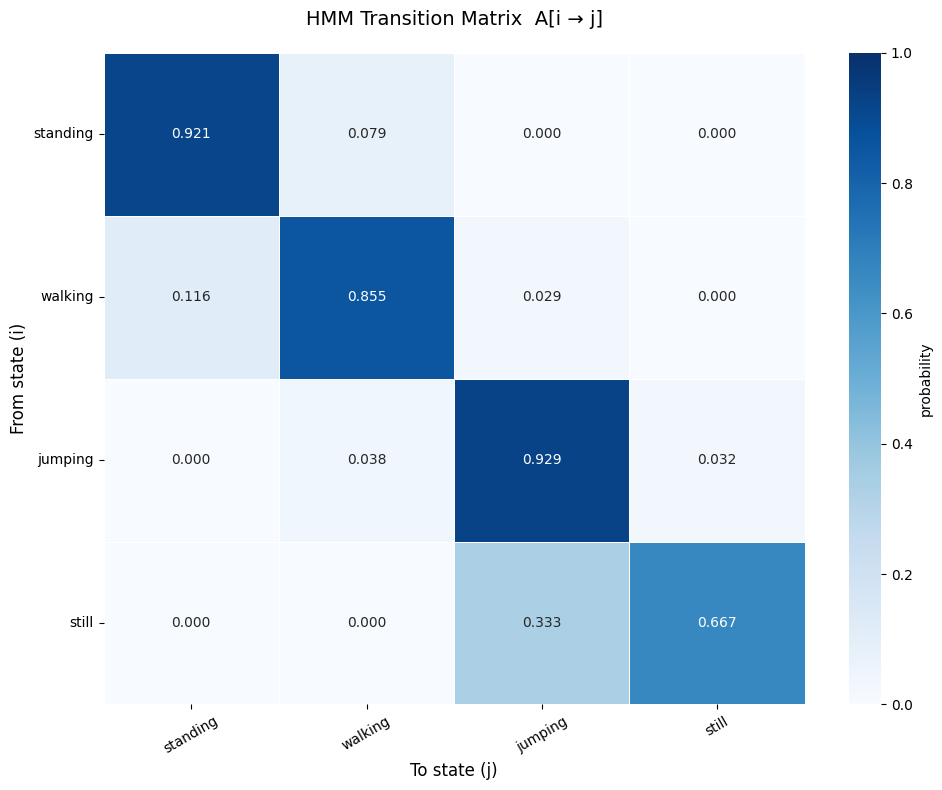

Diagonal entries (self-loop probabilities):
  standing  : P(stay) = 0.921
  walking   : P(stay) = 0.855
  jumping   : P(stay) = 0.929
  still     : P(stay) = 0.667


In [14]:
# ── 10a. Transition Matrix Heatmap ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    A,
    annot=True, fmt='.3f', cmap='Blues',
    xticklabels=activities, yticklabels=activities,
    linewidths=0.5, ax=ax, vmin=0, vmax=1,
    cbar_kws={'label': 'probability'}
)
ax.set_title('HMM Transition Matrix  A[i → j]', fontsize=14, pad=20)
ax.set_xlabel('To state (j)', fontsize=12)
ax.set_ylabel('From state (i)', fontsize=12)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('logs/transition_matrix.png', dpi=150)
plt.show()
print("Diagonal entries (self-loop probabilities):")
for i, act in enumerate(activities):
    print(f"  {act:10s}: P(stay) = {A[i,i]:.3f}")

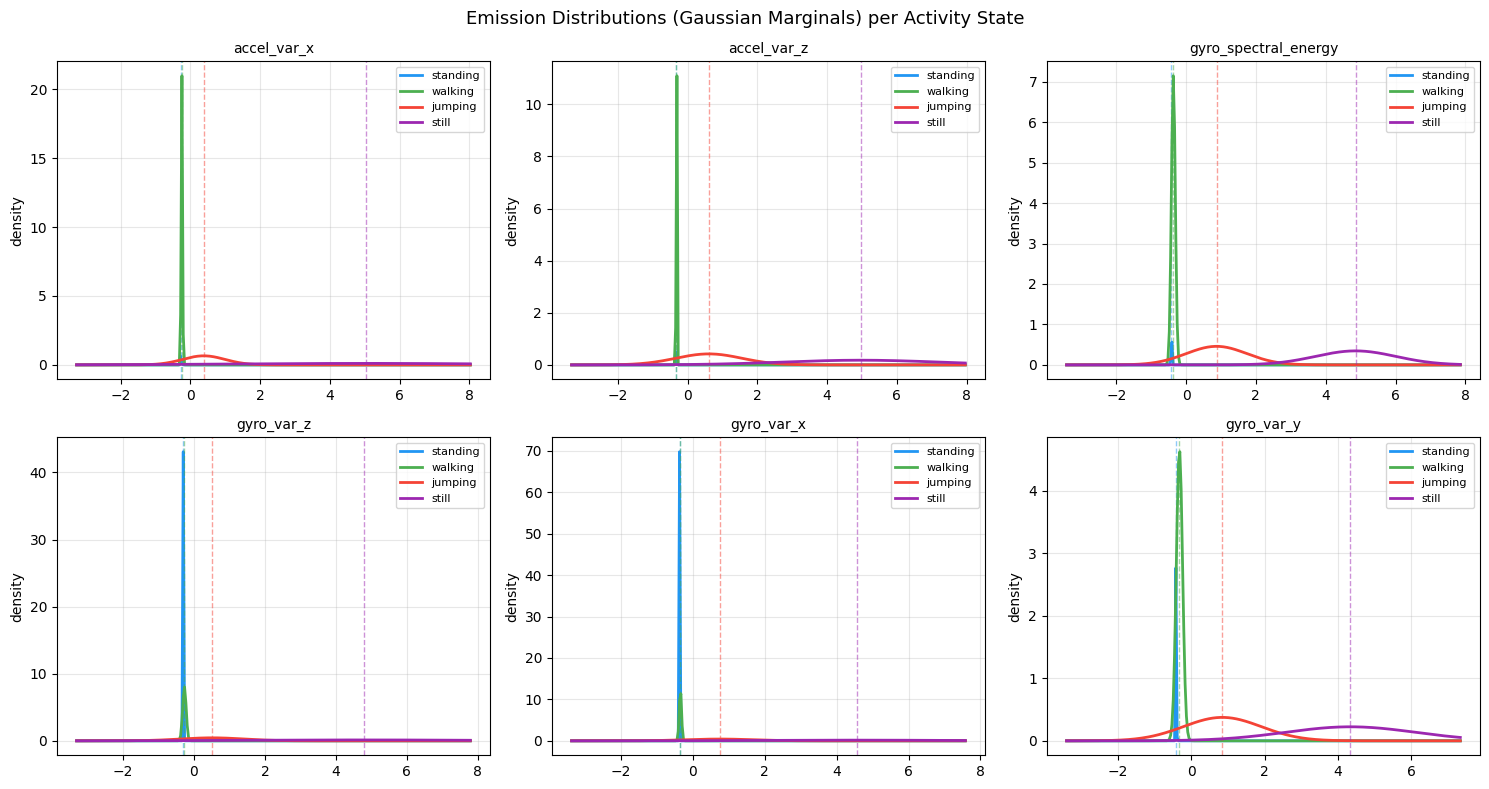

In [28]:
# ── Emission Probability Plots ──────────────────────────────────────────
# Plot the marginal Gaussian emission for each state over the 6 most discriminative features (by total variance across state means).

state_means_df = pd.DataFrame(means, columns=feature_names, index=activities)
feature_spread = state_means_df.std(axis=0).sort_values(ascending=False)
top_features   = feature_spread.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Emission Distributions (Gaussian Marginals) per Activity State',
             fontsize=13)

colors = {'standing': '#2196F3', 'walking': '#4CAF50',
          'jumping': '#F44336', 'still': '#9C27B0'}

for idx, feat in enumerate(top_features):
    ax      = axes[idx // 3, idx % 3]
    fi      = feature_names.index(feat)
    x_range = np.linspace(means[:, fi].min() - 3, means[:, fi].max() + 3, 300)

    for s, act in enumerate(activities):
        mu  = means[s, fi]
        sig = np.sqrt(covars[s, fi, fi])         
        pdf = (1 / (sig * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_range - mu) / sig) ** 2)
        ax.plot(x_range, pdf, label=act, color=colors[act], linewidth=2)
        ax.axvline(mu, color=colors[act], linestyle='--', alpha=0.5, linewidth=1)

    ax.set_title(feat, fontsize=10)
    ax.set_ylabel('density')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('logs/emission_probs.png', dpi=150)
plt.show()

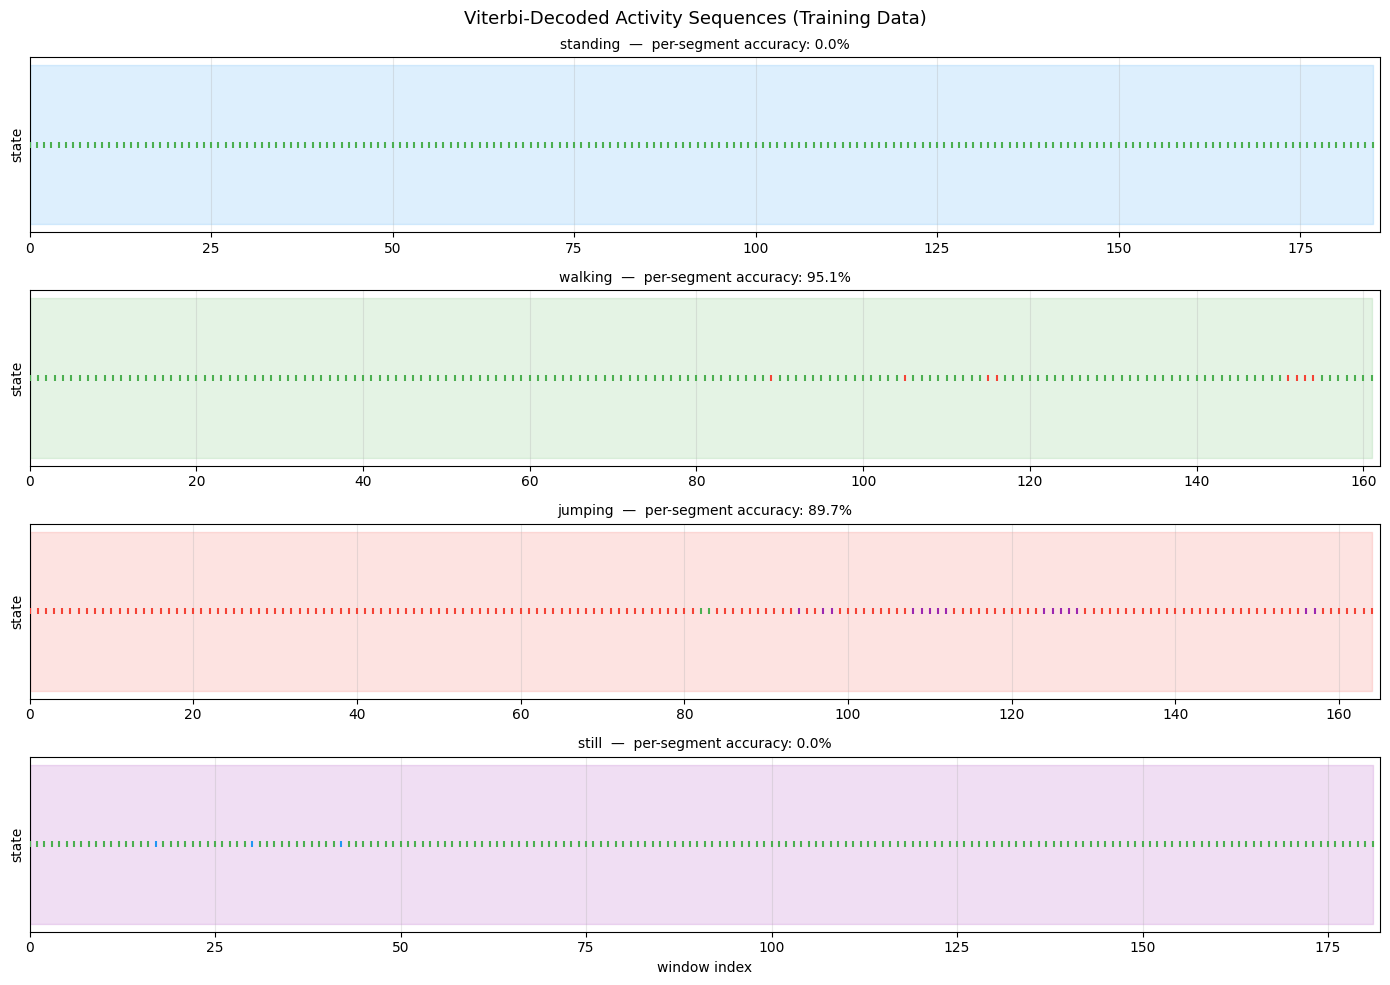

In [16]:
# ── Decoded Sequence Plots ───────────────────────────────────────────────
# Shows the Viterbi-decoded state sequence for one representative recording of each activity, plotted alongside the true label.

activity_colors = {0: '#2196F3', 1: '#4CAF50', 2: '#F44336', 3: '#9C27B0'}

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=False)
fig.suptitle('Viterbi-Decoded Activity Sequences (Training Data)', fontsize=13)

for i, (act, state_idx) in enumerate(label_map.items()):
    mask      = y == state_idx
    X_seq     = X[mask]
    T         = len(X_seq)
    path, _, _= viterbi(X_seq, pi, A, means, covars)

    ax = axes[i]
    ax.fill_between(range(T), -0.4, 0.4, color=activity_colors[state_idx],
                    alpha=0.15, label='true')
    decoded_colored = [activity_colors.get(s, '#888') for s in path]
    for t, s in enumerate(path):
        ax.scatter(t, 0, c=activity_colors.get(s, '#888'), s=15,
                   marker='|', zorder=3)

    correct = np.sum(np.array(path) == state_idx) / T
    ax.set_yticks([])
    ax.set_title(f'{act}  —  per-segment accuracy: {correct:.1%}', fontsize=10)
    ax.set_xlim(0, T)
    ax.set_ylabel('state')
    ax.grid(axis='x', alpha=0.3)

axes[-1].set_xlabel('window index')
plt.tight_layout()
plt.savefig('logs/decoded_sequences.png', dpi=150)
plt.show()

## 11. Testing on 2 Unseen Recordings

Two recordings (one from each team member) were held out before training and never seen by the model during Baum-Welch. Features are extracted with the same pipeline and normalized with the **saved scaler** (no re-fitting). Viterbi decoding is then run on each held-out sequence.

In [ ]:
print(f"unseen test recordings (held out before training):")
for r in unseen_records:
    print(f"  {r['file']} ({r['activity']}, {r['member']})")

In [ ]:
with open('outputs/scaler.pkl', 'rb') as f:
    saved_scaler = pickle.load(f)

def predict_sequence(rec):
    windows     = extract_windows(rec['accel'], rec['gyro'])
    feat_list   = [compute_features(aw, gw) for aw, gw in windows]
    feat_df     = pd.DataFrame(feat_list)
    X_unseen    = saved_scaler.transform(feat_df.values)

    path, score, delta = viterbi(X_unseen, pi, A, means, covars)

    pred_labels = [activities[s] for s in path]

    return {
        'file'       : rec['file'],
        'true_label' : rec['activity'],
        'path'       : path,
        'score'      : score,
        'pred_labels': pred_labels,
        'true_labels': [rec['activity']] * len(path),
        'X_unseen'   : X_unseen,
        'n_windows'  : len(path),
    }

test_results = []
for rec in unseen_records:
    res = predict_sequence(rec)
    test_results.append(res)

for res in test_results:
    n_correct = sum(p == label_map[res['true_label']] for p in res['path'])
    print(f"{res['file']}  |  true: {res['true_label']}  |  windows: {res['n_windows']}  "
          f"|  window-level acc: {n_correct / res['n_windows']:.1%}  "
          f"|  log-prob: {res['score']:.2f}")

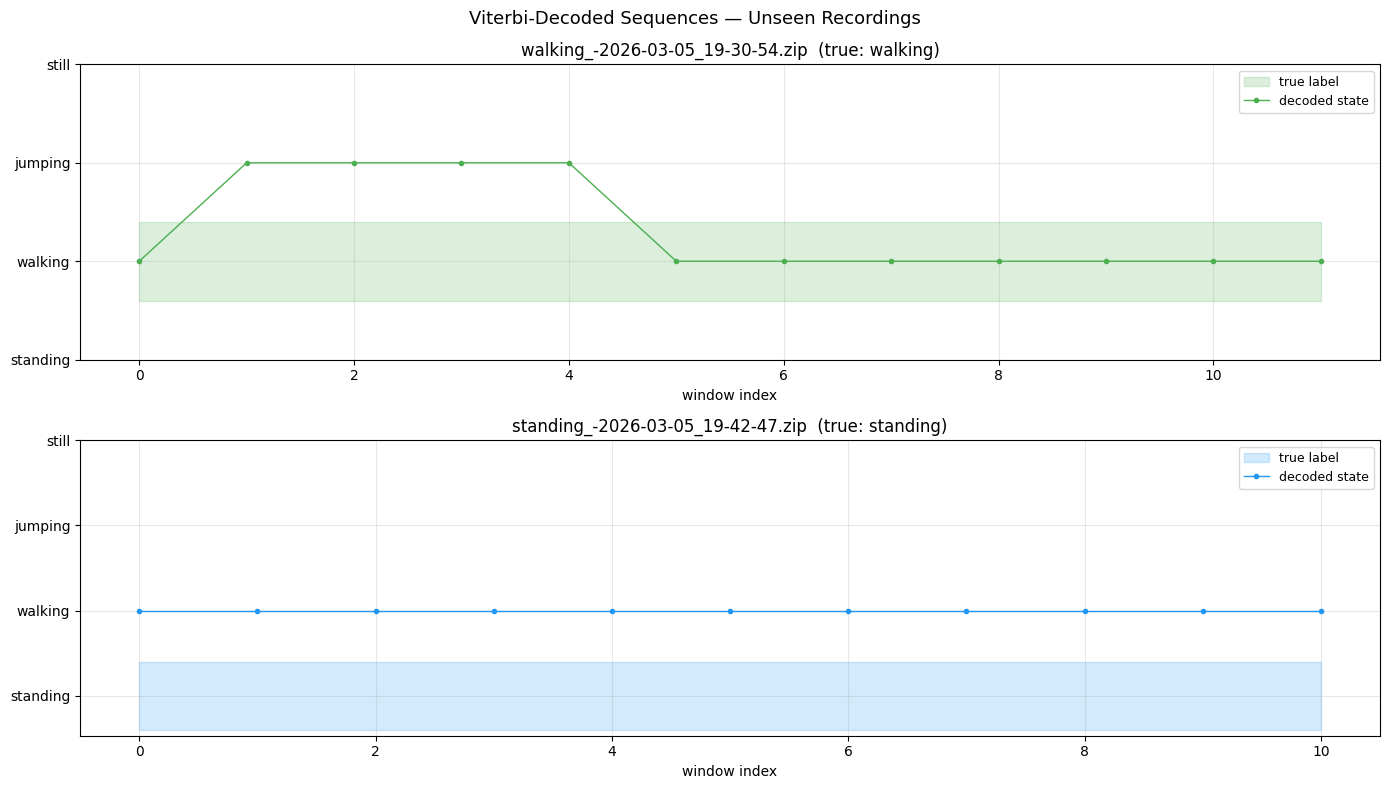

In [19]:
# ── Plot decoded sequences for unseen recordings ──────────────────────────────
state_to_int = label_map
int_to_state = {v: k for k, v in label_map.items()}

fig, axes = plt.subplots(len(test_results), 1,
                         figsize=(14, 4 * len(test_results)), squeeze=False)
fig.suptitle('Viterbi-Decoded Sequences — Unseen Recordings', fontsize=13)

for ax, res in zip(axes[:, 0], test_results):
    T         = res['n_windows']
    true_s    = label_map[res['true_label']]
    path      = res['path']
    time_axis = np.arange(T)

    ax.fill_between(time_axis, true_s - 0.4, true_s + 0.4,
                    color=activity_colors[true_s], alpha=0.2, label='true label')
    ax.plot(time_axis, path, 'o-', markersize=3, linewidth=1,
            color=activity_colors[true_s], label='decoded state')

    ax.set_yticks(list(label_map.values()))
    ax.set_yticklabels(list(label_map.keys()))
    ax.set_xlabel('window index')
    ax.set_title(f"{res['file']}  (true: {res['true_label']})")
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('logs/decoded_unseen.png', dpi=150)
plt.show()

## 12. Per-Activity Metrics: Sensitivity, Specificity, Accuracy

Combine **all decoded windows** (from the two unseen recordings) with all decoded windows from the training set to compute a full evaluation.

| Metric | Formula |
|---|---|
| Sensitivity (Recall) | TP / (TP + FN) |
| Specificity | TN / (TN + FP) |
| Accuracy | (TP + TN) / Total |

These are computed in a **one-vs-rest** fashion for each of the 4 activity classes.

In [20]:
from sklearn.metrics import confusion_matrix, classification_report

# ── Aggregate predictions: run Viterbi over the full training set ─────────────
all_true  = list(y)  
all_pred  = []

# Decode training data file-by-file to respect sequence structure
for rec in records:
    windows   = extract_windows(rec['accel'], rec['gyro'])
    feat_list = [compute_features(aw, gw) for aw, gw in windows]
    if not feat_list:
        continue
    X_rec     = saved_scaler.transform(pd.DataFrame(feat_list).values)
    path, _, _= viterbi(X_rec, pi, A, means, covars)
    all_pred.extend(path)

# Add unseen test predictions
for res in test_results:
    true_s = label_map[res['true_label']]
    all_true.extend([true_s] * res['n_windows'])
    all_pred.extend(res['path'])

all_true = np.array(all_true)
all_pred = np.array(all_pred)

# ── Per-activity one-vs-rest metrics ─────────────────────────────────────────
print(f"{'Activity':<12} {'Sensitivity':>12} {'Specificity':>12} {'Accuracy':>10}  {'TP':>6} {'FP':>6} {'FN':>6} {'TN':>6}")
print("-" * 72)

metrics_rows = []
for act, s in label_map.items():
    tp = np.sum((all_true == s) & (all_pred == s))
    fp = np.sum((all_true != s) & (all_pred == s))
    fn = np.sum((all_true == s) & (all_pred != s))
    tn = np.sum((all_true != s) & (all_pred != s))

    sensitivity  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity  = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    accuracy     = (tp + tn) / len(all_true)

    metrics_rows.append({
        'activity'   : act,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'accuracy'   : accuracy,
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn
    })
    print(f"{act:<12} {sensitivity:>12.3f} {specificity:>12.3f} {accuracy:>10.3f}  "
          f"{tp:>6} {fp:>6} {fn:>6} {tn:>6}")

metrics_df = pd.DataFrame(metrics_rows).set_index('activity')
print("\nOverall window-level accuracy:",
      f"{np.mean(all_true == all_pred):.3f}")

Activity      Sensitivity  Specificity   Accuracy      TP     FP     FN     TN
------------------------------------------------------------------------
standing            0.000        0.994      0.721       0      3    197    518
walking             0.937        0.301      0.455     163    380     11    164
jumping             0.885        0.980      0.958     146     11     19    542
still               0.000        0.972      0.726       0     15    182    521

Overall window-level accuracy: 0.430


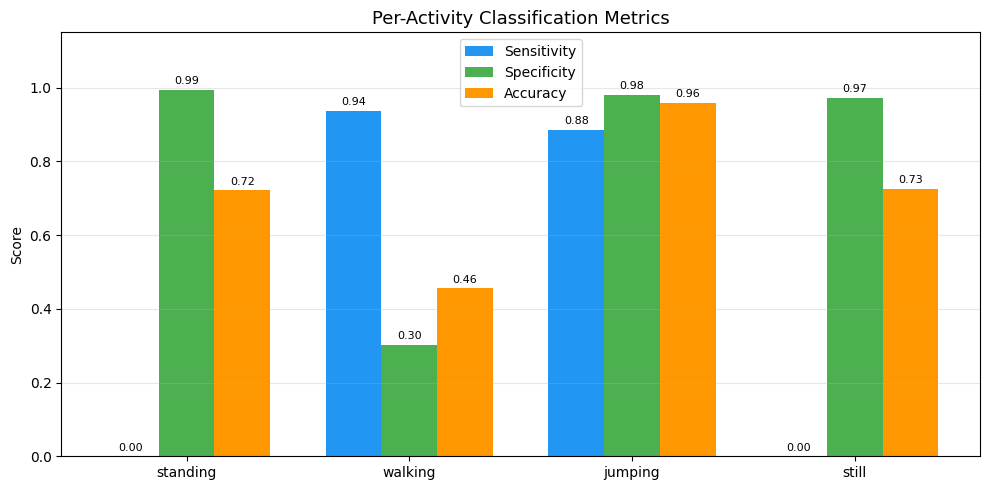

In [21]:
# ── Bar chart of per-activity metrics ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
x   = np.arange(len(activities))
w   = 0.25

bars_sens = ax.bar(x - w,   metrics_df['sensitivity'], w, label='Sensitivity', color='#2196F3')
bars_spec = ax.bar(x,       metrics_df['specificity'], w, label='Specificity', color='#4CAF50')
bars_acc  = ax.bar(x + w,   metrics_df['accuracy'],    w, label='Accuracy',    color='#FF9800')

for bars in (bars_sens, bars_spec, bars_acc):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                f'{h:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(activities)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Per-Activity Classification Metrics', fontsize=13)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('logs/metrics_bar.png', dpi=150)
plt.show()

## 13. Confusion Matrix

The confusion matrix shows the count of true vs. predicted labels across all windows. The diagonal represents correct predictions; off-diagonal entries reveal which activities are confused with each other.

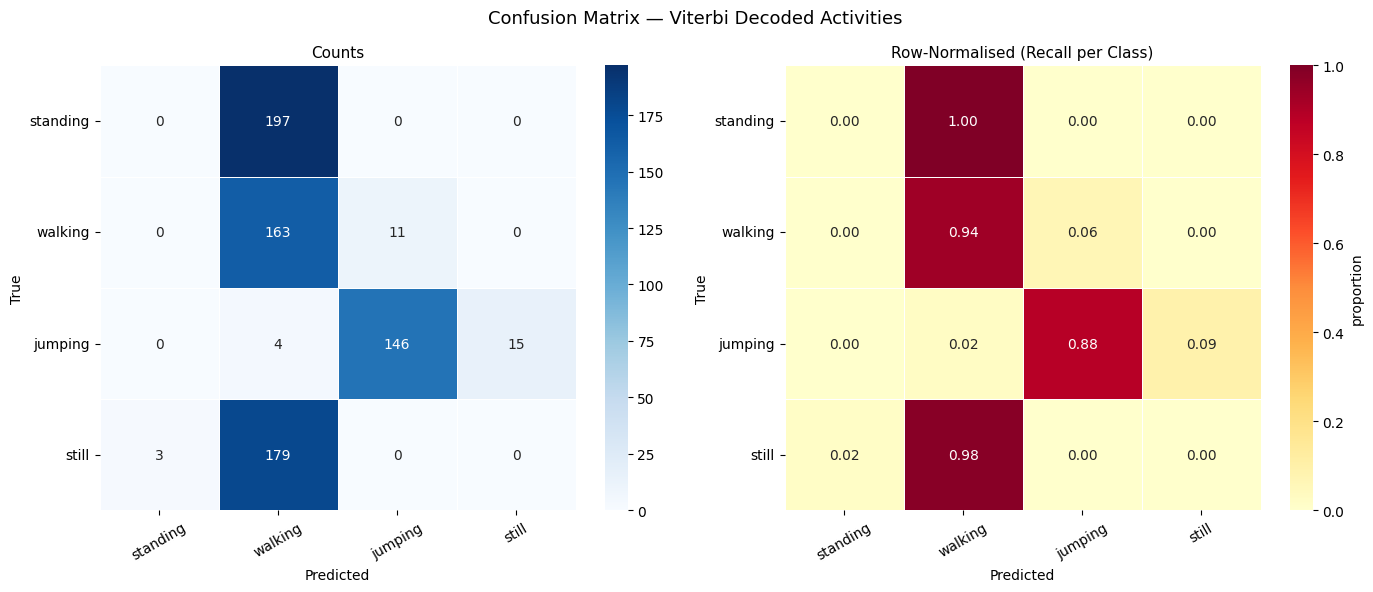


Full classification report:
              precision    recall  f1-score   support

    standing      0.000     0.000     0.000       197
     walking      0.300     0.937     0.455       174
     jumping      0.930     0.885     0.907       165
       still      0.000     0.000     0.000       182

    accuracy                          0.430       718
   macro avg      0.308     0.455     0.340       718
weighted avg      0.286     0.430     0.319       718



In [38]:
cm = confusion_matrix(all_true, all_pred, labels=list(range(n_states)))

# ── Raw count confusion matrix ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Confusion Matrix — Viterbi Decoded Activities', fontsize=13)

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=activities, yticklabels=activities,
    linewidths=0.5, ax=axes[0]
)
axes[0].set_title('Counts', fontsize=11)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=30)
axes[0].tick_params(axis='y', rotation=0)

# ── Normalised (row-normalised = recall) ──────────────────────────────────────
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
    xticklabels=activities, yticklabels=activities,
    vmin=0, vmax=1, linewidths=0.5, ax=axes[1],
    cbar_kws={'label': 'proportion'}
)
axes[1].set_title('Row-Normalised (Recall per Class)', fontsize=11)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=30)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('logs/confusion_matrix.png', dpi=150)
plt.show()

print("\nFull classification report:")
print(classification_report(all_true, all_pred,
                             target_names=activities, digits=3))

In [23]:
# ── Final summary ─────────────────────────────────────────────────────────────
print("PIPELINE SUMMARY")
print("=" * 60)
print(f"  Total windows evaluated  : {len(all_true)}")
print(f"  Overall accuracy         : {np.mean(all_true == all_pred):.3f}")
print()
print("  Per-activity metrics:")
print(metrics_df[['sensitivity','specificity','accuracy']].round(3).to_string())
print()
print("  Saved figures:")
saved_figs = [
    'logs/raw_signals.png',
    'logs/feature_distributions.png',
    'logs/transition_matrix.png',
    'logs/emission_probs.png',
    'logs/decoded_sequences.png',
    'logs/decoded_unseen.png',
    'logs/metrics_bar.png',
    'logs/confusion_matrix.png',
]
for f in saved_figs:
    print(f"    {f}")

PIPELINE SUMMARY
  Total windows evaluated  : 718
  Overall accuracy         : 0.430

  Per-activity metrics:
          sensitivity  specificity  accuracy
activity                                    
standing        0.000        0.994     0.721
walking         0.937        0.301     0.455
jumping         0.885        0.980     0.958
still           0.000        0.972     0.726

  Saved figures:
    logs/raw_signals.png
    logs/feature_distributions.png
    logs/transition_matrix.png
    logs/emission_probs.png
    logs/decoded_sequences.png
    logs/decoded_unseen.png
    logs/metrics_bar.png
    logs/confusion_matrix.png
